# LSTM Fall Detection — Binary (3-second trim)

**Input**  : `data/processed_v2/X.npy`, `y.npy`  
**Output** : `models/lstm_v3.h5`, `models/scaler_v3.pkl`, `models/report_v3.json`

Data is pre-trimmed to 300 packets (3 seconds) per sample to focus on the CSI spike at the moment of fall, excluding the post-fall lying period.

| Label | Class |
|---|---|
| 0 | fall (fall_A + fall_B + fall_C merged) |
| 1 | non_fall |

## 1. Import & Config

In [1]:
import os, json, pickle
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
BASE_DIR         = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
PROCESSED_V2_DIR = os.path.join(BASE_DIR, "data", "processed_v2")
MODEL_DIR        = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

CLASS_NAMES  = ["fall", "non_fall"]
N_CLASSES    = 2
SEQUENCE_LEN = 10
N_FEATURES   = 416
BATCH_SIZE   = 32
EPOCHS       = 150
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15
RANDOM_STATE = 42

print("Config OK")
print(f"PROCESSED_V2_DIR : {PROCESSED_V2_DIR}")
print(f"MODEL_DIR        : {MODEL_DIR}")

Config OK
PROCESSED_V2_DIR : /Users/peerawootposh/TDG/fall_detection_backend/ml_service/data/processed_v2
MODEL_DIR        : /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models


## 2. Load Data

In [3]:
X = np.load(os.path.join(PROCESSED_V2_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_V2_DIR, "y.npy"))

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print("Class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = int(np.sum(y == i))
    pct   = count / len(y) * 100
    print(f"  {name:10s} ({i}) : {count:5d} ({pct:.1f}%)")

X shape : (1260, 416)
y shape : (1260,)
Class distribution:
  fall       (0) :   900 (71.4%)
  non_fall   (1) :   360 (28.6%)


## 3. Build Sequences

In [4]:
def build_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        window_labels = y[i:i + seq_len]
        if len(set(window_labels)) == 1:
            Xs.append(X[i:i + seq_len])
            ys.append(window_labels[-1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

Xs, ys = build_sequences(X, y, SEQUENCE_LEN)
print(f"Sequences : {Xs.shape}")
print(f"Labels    : {ys.shape}")
print("Sequence class distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = int(np.sum(ys == i))
    pct   = count / len(ys) * 100
    print(f"  {name:10s} ({i}) : {count:5d} ({pct:.1f}%)")

Sequences : (1242, 10, 416)
Labels    : (1242,)
Sequence class distribution:
  fall       (0) :   891 (71.7%)
  non_fall   (1) :   351 (28.3%)


## 4. Train / Val / Test Split

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    Xs, ys, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=ys
)
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 868
Val   : 187
Test  : 187


## 5. Normalize

In [6]:
scaler = StandardScaler()
_, seq_len, n_feat = X_train.shape

scaler.fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(X_train.shape)
X_val   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

scaler_path = os.path.join(MODEL_DIR, "scaler_v3.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Normalized  scaler -> {scaler_path}")

Normalized  scaler -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/scaler_v3.pkl


## 6. Class Weights

In [7]:
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Class weights:")
for i, w in class_weights.items():
    print(f"  {CLASS_NAMES[i]:10s} : {w:.3f}")

y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)

Class weights:
  fall       : 0.697
  non_fall   : 1.771


## 7. Build Model

In [8]:
model = Sequential([
    LSTM(128, input_shape=(SEQUENCE_LEN, N_FEATURES), return_sequences=True, dropout=0.3),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(64, return_sequences=True, dropout=0.3),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False, dropout=0.2),
    BatchNormalization(),

    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(N_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

2026-03-13 15:04:47.955952: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-13 15:04:47.956170: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-13 15:04:47.956192: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-13 15:04:47.956381: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-13 15:04:47.956404: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/peerawootposh/TDG/fall_detection_backend/ml_service/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argume

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │       279,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,002 (1.31 MB)

 Trainable params: 343,554 (1.31 MB)

 Non-trainable params: 448 (1.75 KB)

## 8. Train

In [9]:
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(MODEL_DIR, "lstm_v3_best.h5"),
                    monitor="val_accuracy", save_best_only=True, verbose=1),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/150


2026-03-13 15:04:54.795663: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5231 - loss: 0.9478
Epoch 1: val_accuracy improved from None to 0.67914, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5



Epoch 1: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.5530 - loss: 0.8970 - val_accuracy: 0.6791 - val_loss: 0.6214 - learning_rate: 1.0000e-04
Epoch 2/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6075 - loss: 0.7745
Epoch 2: val_accuracy improved from 0.67914 to 0.70588, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5



Epoch 2: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6094 - loss: 0.7635 - val_accuracy: 0.7059 - val_loss: 0.5858 - learning_rate: 1.0000e-04
Epoch 3/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6232 - loss: 0.7466
Epoch 3: val_accuracy improved from 0.70588 to 0.72727, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5


...


Epoch 49: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8433 - loss: 0.3124 - val_accuracy: 0.9572 - val_loss: 0.1299 - learning_rate: 1.0000e-04
Epoch 50/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8409 - loss: 0.3251
Epoch 50: val_accuracy improved from 0.95722 to 0.96791, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5



Epoch 50: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8387 - loss: 0.3204 - val_accuracy: 0.9679 - val_loss: 0.1290 - learning_rate: 1.0000e-04
Epoch 51/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8501 - loss: 0.3173
Epoch 51: val_accuracy improved from 0.96791 to 0.97326, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5



Epoch 51: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8468 - loss: 0.3174 - val_accuracy: 0.9733 - val_loss: 0.1254 - learning_rate: 1.0000e-04
Epoch 52/150
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8376 - loss: 0.3428
Epoch 52: val_accuracy did not improve from 0.97326
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8514 - loss: 0.3235 - val_accuracy: 0.9679 - val_loss: 0.1257 - learning_rate: 1.0000e-04
Epoch 53/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8482 - loss: 0.3228
Epoch 53: val_accuracy did not improve from 0.97326
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8525 - loss: 0.3370 - val_accuracy: 0.9626 - val_loss: 0.1322 - learning_rate: 1.0000e-04
Epoch 54/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8521 - loss: 0.2982
Epoch 54: val_accuracy did not improve from 0.97326
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29m


Epoch 59: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8698 - loss: 0.2432 - val_accuracy: 0.9786 - val_loss: 0.1077 - learning_rate: 1.0000e-04
Epoch 60/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8678 - loss: 0.2960
Epoch 60: val_accuracy improved from 0.97861 to 0.98396, saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5



Epoch 60: finished saving model to /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3_best.h5
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8802 - loss: 0.2749 - val_accuracy: 0.9840 - val_loss: 0.1027 - learning_rate: 1.0000e-04
Epoch 61/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8667 - loss: 0.3012
Epoch 61: val_accuracy did not improve from 0.98396
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8629 - loss: 0.3251 - val_accuracy: 0.9786 - val_loss: 0.0993 - learning_rate: 1.0000e-04
Epoch 62/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8953 - loss: 0.2307
Epoch 62: val_accuracy did not improve from 0.98396
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8744 - loss: 0.2505 - val_accuracy: 0.9786 - val_loss: 0.0981 - learning_rate: 1.0000e-04
Epoch 63/150
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8635 - loss: 0.3217
Epoch 63: val_accuracy did not improve from 0.98396
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28m

## 9. History

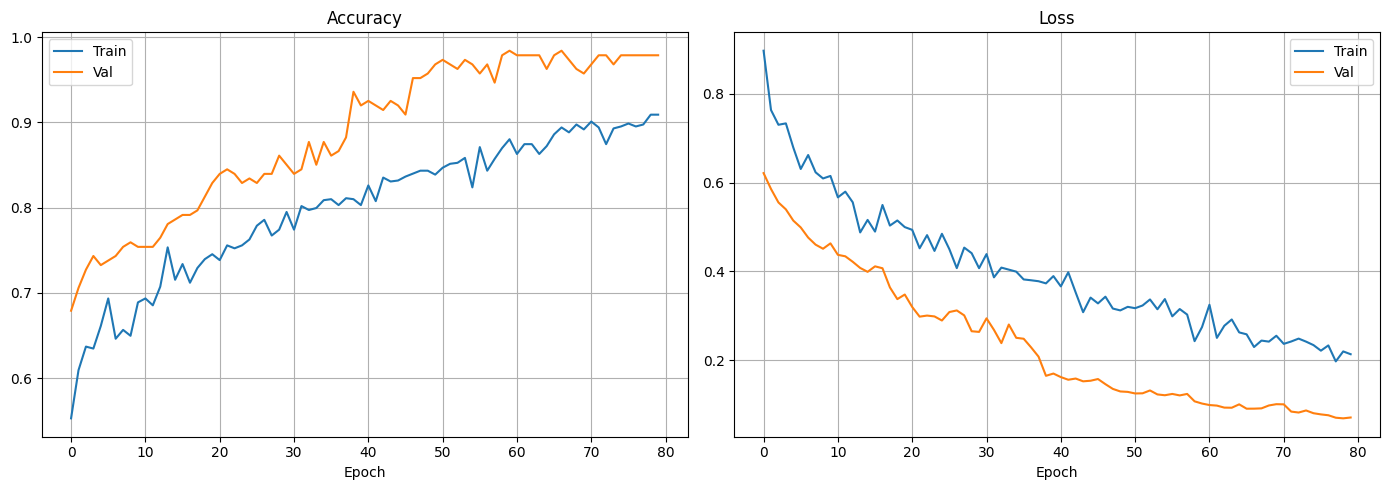

Saved -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/history_v3.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(history.history[metric],          label="Train")
    ax.plot(history.history[f"val_{metric}"], label="Val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "history_v3.png"), dpi=150)
plt.show()
print(f"Saved -> {os.path.join(MODEL_DIR, 'history_v3.png')}")

## 10. Evaluate

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
              precision    recall  f1-score   support

        fall       0.99      0.99      0.99       134
    non_fall       0.96      0.96      0.96        53

    accuracy                           0.98       187
   macro avg       0.97      0.97      0.97       187
weighted avg       0.98      0.98      0.98       187



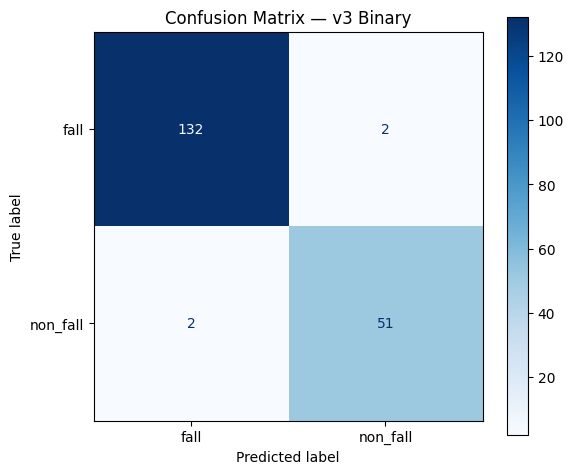

Saved -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/confusion_v3.png

Fall recall (sensitivity): 98.5%  ← must be high


In [11]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix — v3 Binary")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "confusion_v3.png"), dpi=150)
plt.show()
print(f"Saved -> {os.path.join(MODEL_DIR, 'confusion_v3.png')}")

# Highlight fall recall — false negatives are dangerous
report_dict = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
fall_recall = report_dict["fall"]["recall"]
print(f"\nFall recall (sensitivity): {fall_recall*100:.1f}%  ← must be high")

## 11. Save

In [12]:
model_path = os.path.join(MODEL_DIR, "lstm_v3.h5")
model.save(model_path)

report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_data = {
    "created_at":    datetime.now().isoformat(),
    "version":       "v3",
    "n_classes":     N_CLASSES,
    "class_names":   CLASS_NAMES,
    "sequence_len":  SEQUENCE_LEN,
    "n_features":    N_FEATURES,
    "trim_packets":  300,
    "trim_seconds":  3,
    "train_samples": int(X_train.shape[0]),
    "val_samples":   int(X_val.shape[0]),
    "test_samples":  int(X_test.shape[0]),
    "test_accuracy": float(report["accuracy"]),
    "fall_recall":   float(report["fall"]["recall"]),
    "class_report":  report,
}
report_path = os.path.join(MODEL_DIR, "report_v3.json")
with open(report_path, "w") as f:
    json.dump(report_data, f, indent=2, ensure_ascii=False)

print(f"model   -> {model_path}")
print(f"report  -> {report_path}")
print(f"Test Accuracy  : {report['accuracy']*100:.1f}%")
print(f"Fall Recall    : {report['fall']['recall']*100:.1f}%")

model   -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/lstm_v3.h5
report  -> /Users/peerawootposh/TDG/fall_detection_backend/ml_service/models/report_v3.json
Test Accuracy  : 97.9%
Fall Recall    : 98.5%
